In [18]:
import os
from google.colab import drive

# 1. Mount Google Drive
try:
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive', force_remount=True)
    print("Drive is accessible.")
except Exception as e:
    print(f"Drive mount failed: {e}")

# 2. Define Paths - Updated based on ls output
test_src = '/content/drive/MyDrive/data/test'
test_dst = '/content/data/test'
val_src = '/content/drive/MyDrive/data/validation'
val_dst = '/content/data/val'
model_src_dir = '/content/drive/MyDrive/carla_models'
models_to_copy = [
    'has_pedestrian_best.pth',
    'has_vehicle_best.pth',
    'has_traffic_light_best.pth'
]

# 3. Create Local Directories
os.makedirs(test_dst, exist_ok=True)
os.makedirs(val_dst, exist_ok=True)

# 4. Copy Dataset function
def copy_data(src, dst, name):
    if os.path.exists(src):
        print(f"Copying {name} dataset from Drive to local session...")
        !cp -r "{src}/"* "{dst}/"
        labels_path = os.path.join(dst, 'labels.csv')
        img_path = os.path.join(dst, 'rgb-front')
        if os.path.exists(labels_path) and os.path.exists(img_path):
            print(f"Successfully verified {name} split.")
        else:
            print(f"Warning: Verification failed for {name} split.")
    else:
        print(f"Source {name} directory not found: {src}")

copy_data(test_src, test_dst, "test")
copy_data(val_src, val_dst, "validation")

# 5. Copy Model Weights
print("Copying model files...")
for model_file in models_to_copy:
    src_path = os.path.join(model_src_dir, model_file)
    if os.path.exists(src_path):
        !cp "{src_path}" "/content/{model_file}"
        print(f"Copied {model_file}")

print("Setup complete.")

Drive is accessible.
Copying test dataset from Drive to local session...
Successfully verified test split.
Copying validation dataset from Drive to local session...
Successfully verified validation split.
Copying model files...
Copied has_pedestrian_best.pth
Copied has_vehicle_best.pth
Copied has_traffic_light_best.pth
Setup complete.


In [12]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import os

# 1. Configuration and Paths
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_dir = "/content/data/test/rgb-front"
labels_csv = "/content/data/test/labels.csv"
model_weights = {
    "pedestrian": "/content/has_pedestrian_best.pth",
    "vehicle": "/content/has_vehicle_best.pth",
    "traffic_light": "/content/has_traffic_light_best.pth"
}

# 2. Dataset Definition
class CarlaDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        if 'frame' in self.df.columns:
            self.img_col = 'frame'
        elif 'image_path' in self.df.columns:
            self.img_col = 'image_path'
        else:
            raise KeyError(f"Image column not found. Available: {list(self.df.columns)}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        raw_val = self.df.iloc[idx][self.img_col]

        # Try multiple common CARLA filename patterns
        # 1. Direct string, 2. Zero-padded 6 digits, 3. Raw number
        filename = str(raw_val)
        if not filename.lower().endswith(('.jpg', '.png')):
            # Try padding if it looks like a frame index
            if filename.isdigit():
                filename = filename.zfill(6) + ".jpg"
            else:
                filename += ".jpg"

        img_name = os.path.join(self.img_dir, os.path.basename(filename))

        # Fallback check if 6-digit padding fails, try without padding
        if not os.path.exists(img_name):
             fallback = os.path.join(self.img_dir, f"{raw_val}.jpg")
             if os.path.exists(fallback): img_name = fallback

        image = Image.open(img_name).convert('RGB')

        labels = {
            "pedestrian": float(self.df.iloc[idx]['has_pedestrian']),
            "vehicle": float(self.df.iloc[idx]['has_vehicle']),
            "traffic_light": float(self.df.iloc[idx]['has_traffic_light'])
        }

        if self.transform:
            image = self.transform(image)

        return image, labels

# 3. Model Loading Helper
def load_resnet_model(weight_path):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 1)
    checkpoint = torch.load(weight_path, map_location=device)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model

# 4. Calibration Error Calculation
def compute_ece(probs, labels, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (probs > bin_lower) & (probs <= bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(labels[in_bin])
            avg_confidence_in_bin = np.mean(probs[in_bin])
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    return ece

# 5. Execution
preprocess = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_dataset = CarlaDataset(labels_csv, test_dir, transform=preprocess)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

results = {key: {"probs": [], "labels": []} for key in model_weights.keys()}

with torch.no_grad():
    for task, weight_path in model_weights.items():
        print(f"Evaluating {task} model...")
        model = load_resnet_model(weight_path)
        all_probs = []
        all_labels = []
        for inputs, labels_dict in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).squeeze().cpu().numpy()
            if probs.ndim == 0: probs = np.array([probs])
            all_probs.extend(probs)
            all_labels.extend(labels_dict[task].numpy())

        results[task]['probs'] = np.array(all_probs)
        results[task]['labels'] = np.array(all_labels)
        ece_score = compute_ece(results[task]['probs'], results[task]['labels'])
        print(f"ECE for {task}: {ece_score:.4f}")
        del model
        torch.cuda.empty_cache()

Evaluating pedestrian model...
ECE for pedestrian: 0.0598
Evaluating vehicle model...
ECE for vehicle: 0.0676
Evaluating traffic_light model...
ECE for traffic_light: 0.0260


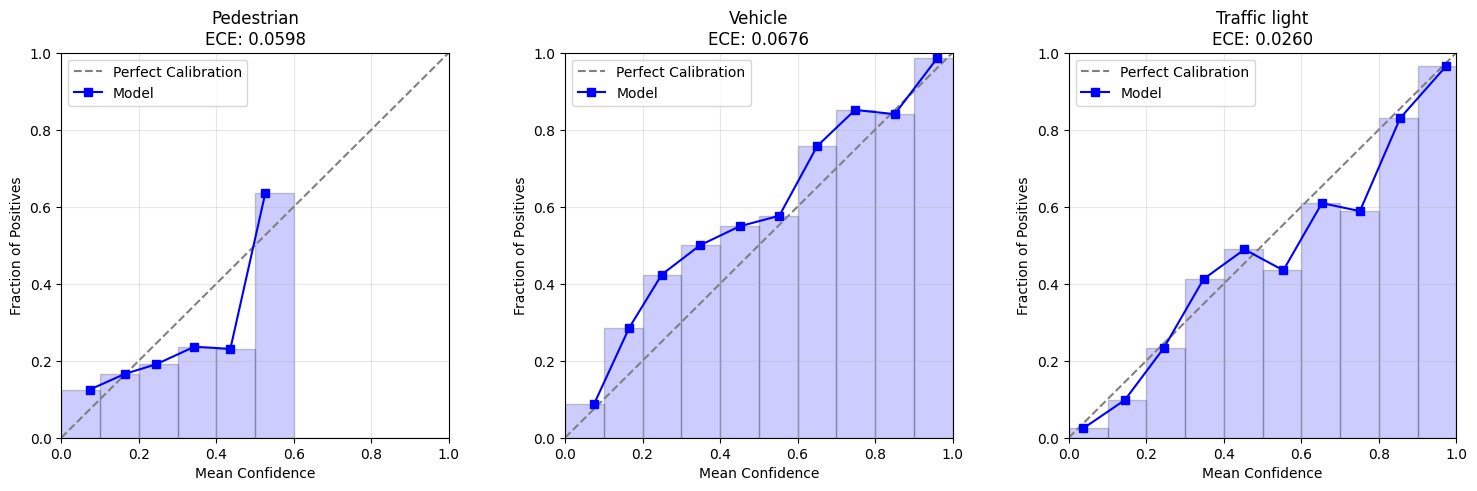

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Helper function to get bin statistics
def get_calibration_stats(probs, labels, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    confidences = []
    accuracies = []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (probs > bin_lower) & (probs <= bin_upper)
        if np.sum(in_bin) > 0:
            accuracies.append(np.mean(labels[in_bin]))
            confidences.append(np.mean(probs[in_bin]))
        else:
            accuracies.append(None)
            confidences.append(None)

    return confidences, accuracies, bin_boundaries

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.3)

for i, (task, data) in enumerate(results.items()):
    ax = axes[i]
    p = np.array(data['probs'])
    l = np.array(data['labels'])

    if len(p) == 0:
        ax.set_title(f"{task} (No Data)")
        continue

    ece = compute_ece(p, l)
    conf, acc, bins = get_calibration_stats(p, l)

    # Plot perfect calibration line
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

    # Filter out None values for the line plot
    plot_conf = [c for c in conf if c is not None]
    plot_acc = [a for a in acc if a is not None]
    ax.plot(plot_conf, plot_acc, marker='s', color='blue', label='Model')

    # Plot bars for the bins
    bin_centers = (bins[:-1] + bins[1:]) / 2
    plot_bars = [a if a is not None else 0 for a in acc]
    ax.bar(bin_centers, plot_bars, width=0.1, alpha=0.2, color='blue', edgecolor='black')

    ax.set_xlabel("Mean Confidence")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title(f"{task.replace('_', ' ').capitalize()}\nECE: {ece:.4f}")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.savefig("reliability_diagrams.png", dpi=300, bbox_inches='tight')
plt.show()

exercise 7.5


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms
import os

# 1. Configuration
val_dir = "/content/data/val/rgb-front"
val_labels_csv = "/content/data/val/labels.csv"
test_dir = "/content/data/test/rgb-front"
test_labels_csv = "/content/data/test/labels.csv"

transforms_config = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Data Collection Helper
def collect_logits_and_labels(model, dataloader, task_key):
    model.eval()
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels_dict in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs).squeeze()
            if outputs.dim() == 0: outputs = outputs.unsqueeze(0)
            all_logits.append(outputs.cpu())
            all_labels.append(labels_dict[task_key])
    return torch.cat(all_logits), torch.cat(all_labels)

# STEP 1 & 2: Load Data and Find Best T
tasks = ["pedestrian", "vehicle", "traffic_light"]
val_dataset = CarlaDataset(val_labels_csv, val_dir, transform=transforms_config)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_dataset = CarlaDataset(test_labels_csv, test_dir, transform=transforms_config)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

temperatures = np.arange(0.5, 3.1, 0.1)
calibration_results = {}

print(f"{'Model':<15} | {'Best T':<8} | {'Min NLL':<10}")
print("-" * 40)

for task in tasks:
    model = load_resnet_model(model_weights[task])
    val_logits, val_labels = collect_logits_and_labels(model, val_loader, task)

    # Convert to float to avoid dtype mismatch with scaled_probs
    val_labels = val_labels.float()

    best_t = 1.0
    min_nll = float('inf')

    for t_val in temperatures:
        t_tensor = torch.tensor([t_val], dtype=torch.float32)
        scaled_probs = torch.sigmoid(val_logits / t_tensor)
        # Ensure target is same type as input
        nll = F.binary_cross_entropy(scaled_probs, val_labels).item()

        if nll < min_nll:
            min_nll = nll
            best_t = t_val

    print(f"{task:<15} | {best_t:<8.1f} | {min_nll:<10.4f}")

    # STEP 3: Evaluation on Test Set
    test_logits, test_labels = collect_logits_and_labels(model, test_loader, task)
    test_labels_np = test_labels.numpy()

    # ECE Before
    probs_before = torch.sigmoid(test_logits).numpy()
    ece_before = compute_ece(probs_before, test_labels_np)

    # ECE After
    probs_after = torch.sigmoid(test_logits / best_t).numpy()
    ece_after = compute_ece(probs_after, test_labels_np)

    calibration_results[task] = {
        "best_t": best_t,
        "ece_before": ece_before,
        "ece_after": ece_after
    }

    del model
    torch.cuda.empty_cache()

# STEP 4: Summary Table
print("\nSummary Table:")
print(f"{'Model':<15} | {'Best T':<8} | {'ECE Before':<12} | {'ECE After':<12}")
print("-" * 60)
for task, res in calibration_results.items():
    print(f"{task:<15} | {res['best_t']:<8.1f} | {res['ece_before']:<12.4f} | {res['ece_after']:<12.4f}")

Model           | Best T   | Min NLL   
----------------------------------------
pedestrian      | 1.2      | 0.5767    
vehicle         | 1.1      | 0.4716    
traffic_light   | 0.8      | 0.1965    

Summary Table:
Model           | Best T   | ECE Before   | ECE After   
------------------------------------------------------------
pedestrian      | 1.2      | 0.0598       | 0.0950      
vehicle         | 1.1      | 0.0676       | 0.0724      
traffic_light   | 0.8      | 0.0260       | 0.0412      


In [21]:
import torch
import numpy as np
import pandas as pd

# 1. Setup Constants
C_FN = 100
C_FP = 1
TAU_STAR = 0.0099
T_OPT = 1.2
TASK = 'pedestrian'

# 2. Get Logits and Labels from Test Set
# Reusing helper from previous cells to ensure consistency
model = load_resnet_model(model_weights[TASK])
test_logits, test_labels = collect_logits_and_labels(model, test_loader, TASK)
test_labels = test_labels.float()

def evaluate_cost(logits, labels, temperature, threshold):
    # Apply temperature scaling and sigmoid
    probs = torch.sigmoid(logits / temperature)
    preds = (probs >= threshold).float()

    # Calculate FN (Actual 1, Pred 0) and FP (Actual 0, Pred 1)
    fn = torch.sum((labels == 1.0) & (preds == 0.0)).item()
    fp = torch.sum((labels == 0.0) & (preds == 1.0)).item()
    total_cost = (C_FN * fn) + (C_FP * fp)

    return fn, fp, total_cost

# 3. Calculate for the 4 Scenarios
scenarios = [
    ("Uncalibrated", 1.0, 0.5),
    ("Uncalibrated", 1.0, TAU_STAR),
    ("Temp-Scaled (T=1.2)", T_OPT, 0.5),
    ("Temp-Scaled (T=1.2)", T_OPT, TAU_STAR)
]

results_grid = {}

print(f"Detailed Results for {TASK.capitalize()}:")
print("-" * 50)
for name, t, tau in scenarios:
    fn, fp, cost = evaluate_cost(test_logits, test_labels, t, tau)
    results_grid[(name, tau)] = cost
    print(f"{name} (τ={tau}):")
    print(f"  #FN: {int(fn)}, #FP: {int(fp)} -> Total Cost L: {cost:,.0f}\n")

# 4. Print Summary Table
print("Summary Table (Total Loss L):")
print(f"{'Model Type':<25} | {'τ=0.5':<12} | {'τ=τ*=0.0099':<12}")
print("-" * 55)

row_names = ["Uncalibrated", "Temp-Scaled (T=1.2)"]
for row in row_names:
    l_05 = results_grid[(row, 0.5)]
    l_tau = results_grid[(row, TAU_STAR)]
    print(f"{row:<25} | {l_05:<12.0f} | {l_tau:<12.0f}")

Detailed Results for Pedestrian:
--------------------------------------------------
Uncalibrated (τ=0.5):
  #FN: 699, #FP: 4 -> Total Cost L: 69,904

Uncalibrated (τ=0.0099):
  #FN: 0, #FP: 2894 -> Total Cost L: 2,894

Temp-Scaled (T=1.2) (τ=0.5):
  #FN: 699, #FP: 4 -> Total Cost L: 69,904

Temp-Scaled (T=1.2) (τ=0.0099):
  #FN: 0, #FP: 2894 -> Total Cost L: 2,894

Summary Table (Total Loss L):
Model Type                | τ=0.5        | τ=τ*=0.0099 
-------------------------------------------------------
Uncalibrated              | 69904        | 2894        
Temp-Scaled (T=1.2)       | 69904        | 2894        
